## Supplementary Figure 2

Enviorment: env 1

In [10]:
import pandas as pd
import pickle
import os
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix
from scipy.stats import sem
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from sklearn.metrics import balanced_accuracy_score
import seaborn as sns
import textwrap

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/")
from utils import wrap_labels, bl_clean

In [2]:
dpi = 300
font_size = 12
fig_size = 5
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

In [3]:
import re

def get_test_feat_imp(imp_df, save_path, n_pop=10, feats=8):
    """
    get the feature importance heatmaps
    """
    
    pw_cols = [f"PW{i}" for i in range(1, n_pop + 1)]
    
    heatmap_raw = pd.DataFrame(index=imp_df.index)
    for i in range(1, n_pop + 1):
        if ('imp', i) in imp_df.columns:
            heatmap_raw[f"PW{i}"] = imp_df[('imp', i)].values
        elif i in imp_df.columns:
            heatmap_raw[f"PW{i}"] = imp_df[i].values
    
    heatmap_raw.index = pd.Series(heatmap_raw.index).map(bl_clean).tolist()
    heatmap_raw = heatmap_raw.astype(float)
    
    heatmap_raw = heatmap_raw.fillna(0)
    
    def get_base_feature(feat_name):
        """Strip trailing model type suffix like LR, RF, XGB to get the base feature name."""
        match = re.match(r'^(.*?)\s+(LR|RF|XGB)$', feat_name)
        if match:
            return match.group(1), match.group(2)
        return feat_name, ''
    
    base_names = []
    model_types_list = []
    for feat in heatmap_raw.index:
        base, model = get_base_feature(feat)
        base_names.append(base)
        model_types_list.append(model)
    
    heatmap_raw['base_feature'] = base_names
    heatmap_raw['model_type_suffix'] = model_types_list
    
    # group by base feature and sum importances
    agg_df = heatmap_raw.groupby('base_feature')[pw_cols].sum()
    
    # build the display name with model types in parentheses
    model_suffixes_per_base = heatmap_raw.groupby('base_feature')['model_type_suffix'].apply(
        lambda x: sorted(set(s for s in x if s != ''))
    )
    
    display_names = {}
    for base in agg_df.index:
        suffixes = model_suffixes_per_base.get(base, [])
        if suffixes:
            display_names[base] = f"{base} ({'/'.join(suffixes)})"
        else:
            display_names[base] = base
    
    agg_df.index = [display_names[base] for base in agg_df.index]

    agg_df[pw_cols] = agg_df[pw_cols].div(agg_df[pw_cols].sum(axis=0), axis=1)
    
    # sort by prevalence (number of non-zero PWs), then by mean importance as tiebreaker
    agg_df['prevalence'] = (agg_df[pw_cols] > 0).sum(axis=1)
    agg_df['mean_imp'] = agg_df[pw_cols].mean(axis=1)
    agg_df = agg_df.sort_values(['prevalence', 'mean_imp'], ascending=[False, False])
    agg_df = agg_df.drop(columns=['prevalence', 'mean_imp'])

    agg_df = agg_df.head(feats)
    
    # plot heatmap
    fig, ax = plt.subplots(figsize=(8, max(5, len(agg_df) * 0.4)), dpi=dpi)
    cbar_kws = {'label': 'Meta-Learner Base Learner Importance'}
    
    sns.heatmap(
        agg_df,
        annot=True,
        fmt=".2f",
        cmap="rocket_r",
        linewidths=0.5,
        ax=ax,
        cbar_kws=cbar_kws,
        mask=(agg_df == 0),
        vmin=0,
        annot_kws={"size": 8}
    )
    
    ax.set_ylabel("Feature Set", fontsize=8)
    ax.tick_params(axis='y', labelsize=8, pad=150)
    ax.set_yticklabels(
        wrap_labels(list(agg_df.index), 30), 
        rotation=0, 
        ha='left',
        fontsize=8
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(8)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_xlabel("Control Group", fontsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [8]:
all_mets = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw/run_20260407_stable/meta_probs_auc_0.5/all_pw_metrics.csv")
result = all_mets.loc[all_mets.groupby('pw')['auc'].idxmax(), ['pw', 'hp', 'auc']]

all_data = []
pw = 1
for pw in range(1, 6):
    all_pw_data = pd.DataFrame({"bl": [], "pw": []})
    hp = result[result["pw"] == pw]["hp"].iloc[0]
    path = f"/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/rev_strat_pec_hc_pw{pw}/run_20260407_stable/meta_probs_auc_0.5/XGBoost/{hp}_oof.pkl"
    with open(path, "rb") as f:
        data = pickle.load(f)
        for i in range(len(list(data[6].keys()))):
            test_i = pd.DataFrame({"pw": pw, "bl": data[3][i].values, f"imp_{list(data[6].keys())[i]}": data[6][list(data[6].keys())[i]].feature_importances_})
            all_pw_data = all_pw_data.merge(test_i, on=["bl", "pw"], how="outer")
    pw += 1
    all_pw_data = all_pw_data.fillna(0)
    all_data.append(all_pw_data)
all_data = pd.concat(all_data)
test_data = all_data[["pw", "bl"]]
test_data["imp"] = all_data[list(set(list(all_data.columns)) - set(["pw", "bl"]))].sum(axis=1)
test_pivot = test_data.pivot_table(test_data, index="bl", aggfunc="sum", columns="pw")

/gpfs/data/oermannlab/users/ca3261/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


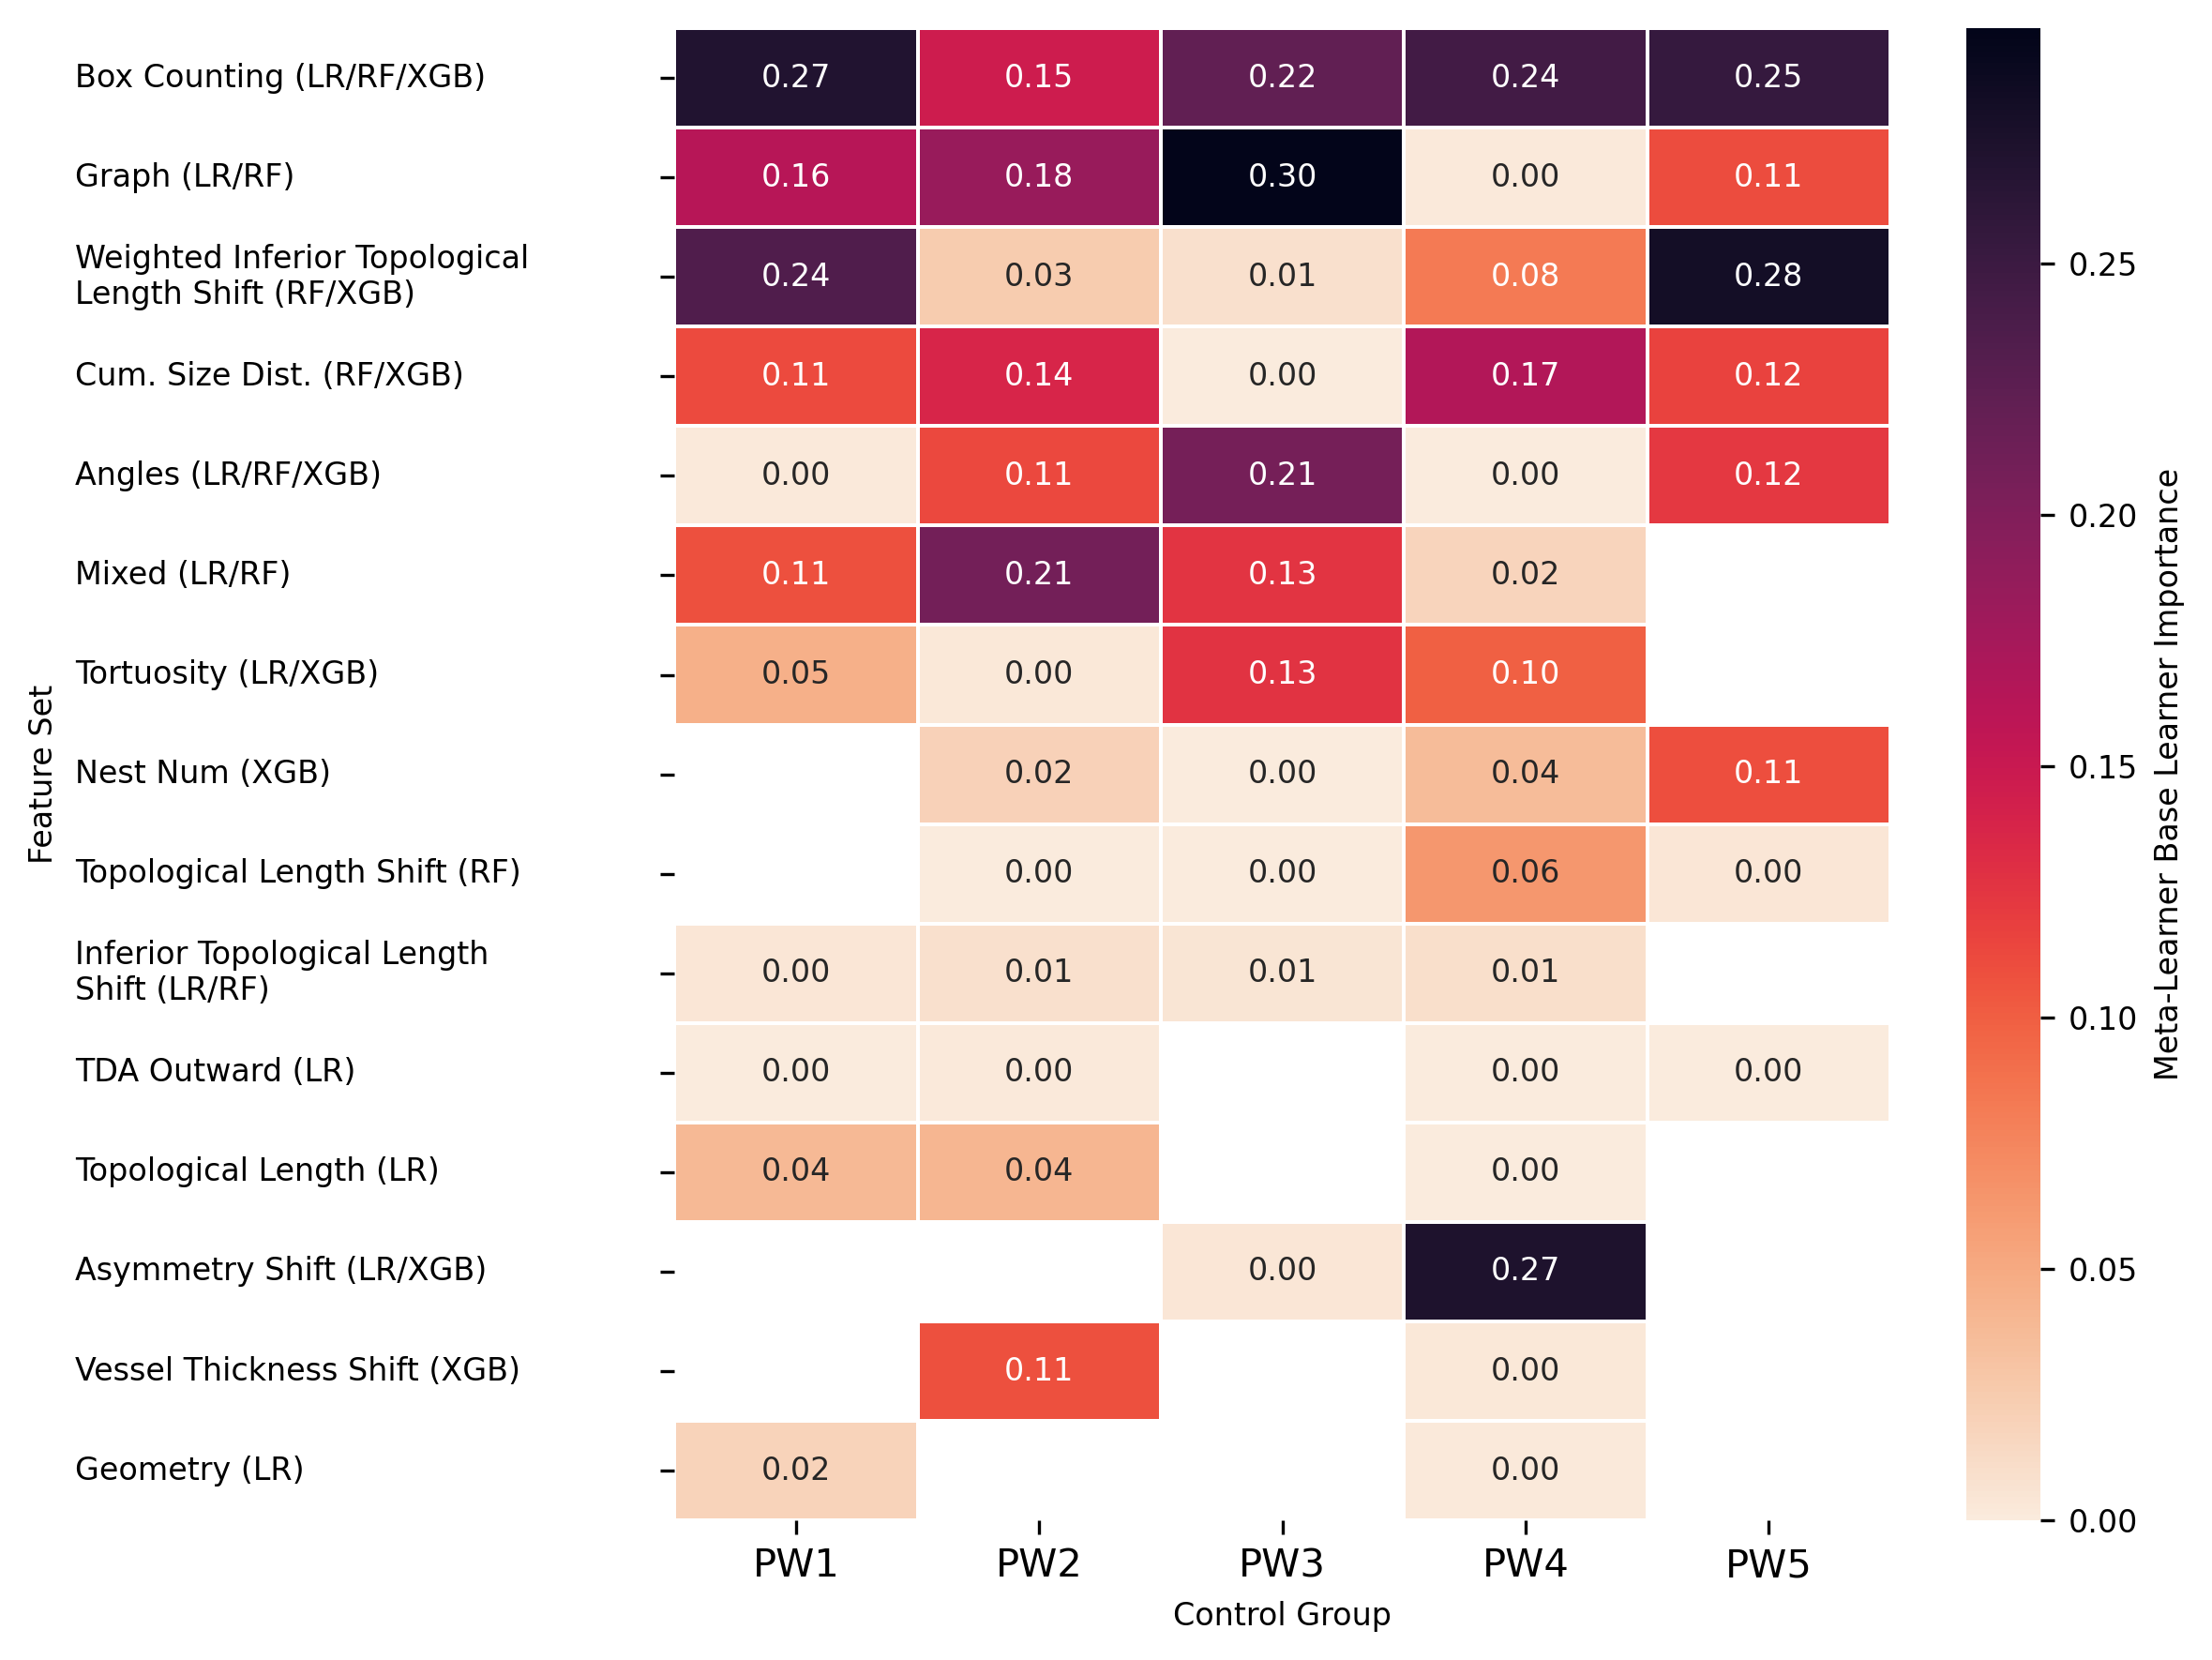

In [11]:
font_size = 12
get_test_feat_imp(test_pivot, feats=16, n_pop=5, save_path="/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/supplementary/fig_2/supplementary_figure_2.pdf")